#try vit model+20 epoch

> Add blockquote



In [ ]:
!pip -q install timm pyyaml

import os, zipfile, random, shutil
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import numpy as np

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

ZIP_PATH_CANDIDATES = ["/content/archive.zip", "/content/Aerial Vehicle Detection.zip"]
zip_candidates = [p for p in ZIP_PATH_CANDIDATES if os.path.exists(p)]
if zip_candidates:
    ZIP_PATH = zip_candidates[0]
else:
    zips = [str(p) for p in Path("/content").glob("*.zip")]
    if not zips:
        raise FileNotFoundError("No .zip found in /content")
    ZIP_PATH = zips[0]

EXTRACT_DIR = Path("/content/data_full_vit_ml_tt")
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

root = EXTRACT_DIR
subdirs = [p for p in root.iterdir() if p.is_dir()]
if len(subdirs) == 1:
    root = subdirs[0]

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
img_files = []
for ext in IMG_EXTS:
    img_files += list(root.rglob(f"*{ext}"))
txt_files = [p for p in root.rglob("*.txt") if p.name != "classes.txt"]

if not img_files or not txt_files:
    raise RuntimeError(f"Could not find images/labels under: {root}")

imgs_by_stem = defaultdict(list)
for p in img_files:
    imgs_by_stem[p.stem].append(p)

labels_by_stem = {p.stem: p for p in txt_files}

pairs = []
for s, lbl in labels_by_stem.items():
    if s in imgs_by_stem:
        pairs.append((imgs_by_stem[s][0], lbl))

if not pairs:
    raise RuntimeError("No matching image/label pairs found")

classes_txt = list(root.rglob("classes.txt"))
id_to_name = None
if classes_txt:
    lines = [ln.strip() for ln in classes_txt[0].read_text().splitlines() if ln.strip()]
    id_to_name = {i: lines[i] for i in range(len(lines))}

DROP_CID = 1


KEEP_NAMES = ["sedan", "bus", "truck", "suv"]
name_to_id = {n:i for i,n in enumerate(KEEP_NAMES)}

ORIG_TO_NEW = {
    "car": "sedan",
    "van": "suv",
    "bus": "bus",
    "truck": "truck",
}

def parse_label(lbl_path: Path):
    lines = [ln.strip() for ln in lbl_path.read_text().splitlines() if ln.strip()]
    cids = []
    for ln in lines:
        parts = ln.split()
        if len(parts) < 5:
            continue
        cids.append(int(float(parts[0])))
    return cids

def cid_name(cid: int):
    if id_to_name and cid in id_to_name:
        return id_to_name[cid].strip()
    return str(cid)

items = []
for img_path, lbl_path in pairs:
    cids = parse_label(lbl_path)
    cids = [c for c in cids if c != DROP_CID]
    orig_names = set(cid_name(c) for c in cids)

    mapped_present = set()
    for on in orig_names:
        if on in ORIG_TO_NEW:
            mapped_present.add(ORIG_TO_NEW[on])

    present = [n for n in KEEP_NAMES if n in mapped_present]
    if not present:
        continue

    y = np.zeros(4, dtype=np.float32)
    for n in present:
        y[name_to_id[n]] = 1.0
    items.append((img_path, y))

if not items:
    raise RuntimeError("No usable images after filtering cycle id=1 and mapping names.")

need_per_class = 5
target_total = 20

per_class_pool = {i: [] for i in range(4)}
for img_path, y in items:
    for i in range(4):
        if y[i] == 1:
            per_class_pool[i].append((img_path, y))

for i in range(4):
    if len(per_class_pool[i]) < need_per_class:
        raise RuntimeError(f"Not enough images containing class {KEEP_NAMES[i]}: {len(per_class_pool[i])}")

selected = []
selected_keys = set()
covered = [0,0,0,0]

for i in range(4):
    pool = per_class_pool[i][:]
    random.shuffle(pool)
    for img_path, y in pool:
        k = str(img_path)
        if k in selected_keys:
            continue
        selected.append((img_path, y))
        selected_keys.add(k)
        for j in range(4):
            if y[j] == 1:
                covered[j] += 1
        if covered[i] >= need_per_class:
            break

remaining = [x for x in items if str(x[0]) not in selected_keys]
random.shuffle(remaining)
while len(selected) < target_total and remaining:
    img_path, y = remaining.pop()
    k = str(img_path)
    if k in selected_keys:
        continue
    selected.append((img_path, y))
    selected_keys.add(k)

if len(selected) != target_total:
    raise RuntimeError(f"Could only select {len(selected)} images")

out_root = Path("/content/vit20_multilabel_train_test")
if out_root.exists():
    shutil.rmtree(out_root)
(out_root/"train/images").mkdir(parents=True, exist_ok=True)
(out_root/"test/images").mkdir(parents=True, exist_ok=True)

random.shuffle(selected)
train_items = selected[:16]
test_items  = selected[16:20]

train_index = out_root/"train_index.txt"
test_index  = out_root/"test_index.txt"

def copy_and_index(items_list, split_dir, index_path):
    with open(index_path, "w") as f:
        for img_path, y in items_list:
            dst = split_dir/"images"/img_path.name
            shutil.copy2(img_path, dst)
            y_str = ",".join(str(int(v)) for v in y.tolist())
            f.write(f"{dst.as_posix()}\t{y_str}\n")

copy_and_index(train_items, out_root/"train", train_index)
copy_and_index(test_items, out_root/"test", test_index)

cov_sel = [0,0,0,0]
for _, y in selected:
    for j in range(4):
        if y[j] == 1:
            cov_sel[j] += 1

print("Selected 20 images total.")
print("Coverage in selected (images containing each class):")
for i,n in enumerate(KEEP_NAMES):
    print(n, cov_sel[i])
print("Train/Test sizes:", len(train_items), len(test_items))

class TxtIndexMultiLabel(Dataset):
    def __init__(self, index_file, tfm):
        self.items = []
        for line in Path(index_file).read_text().splitlines():
            p, y = line.split("\t")
            y_vec = torch.tensor([float(v) for v in y.split(",")], dtype=torch.float32)
            self.items.append((p, y_vec))
        self.tfm = tfm
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        p, y = self.items[idx]
        img = Image.open(p).convert("RGB")
        x = self.tfm(img)
        return x, y

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "vit_base_patch16_224"
img_size = 224
batch_size = 4
epochs = 20
lr = 3e-4

train_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

test_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

train_ds = TxtIndexMultiLabel(train_index, train_tfm)
test_ds  = TxtIndexMultiLabel(test_index, test_tfm)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

model = timm.create_model(model_name, pretrained=True, num_classes=4)

for p in model.parameters():
    p.requires_grad = False

head = None
if hasattr(model, "head"):
    head = model.head
elif hasattr(model, "classifier"):
    head = model.classifier
if head is None:
    raise RuntimeError("Could not find classifier head")

for p in head.parameters():
    p.requires_grad = True

model = model.to(device)

crit = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)

def multilabel_acc(logits, y, thr=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thr).float()
    correct = (preds == y).float().mean().item()
    return correct

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    loss_sum, acc_sum, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            opt.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = crit(logits, yb)
            if train:
                loss.backward()
                opt.step()
        bs = xb.size(0)
        loss_sum += loss.item() * bs
        acc_sum += multilabel_acc(logits, yb) * bs
        n += bs
    return loss_sum / max(n,1), acc_sum / max(n,1)

best_test_acc = -1.0
best_path = out_root/"vit_multilabel_best.pt"

for ep in range(1, epochs+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    te_loss, te_acc = run_epoch(test_loader, train=False)
    if te_acc > best_test_acc:
        best_test_acc = te_acc
        torch.save({
            "model_name": model_name,
            "state_dict": model.state_dict(),
            "class_names": KEEP_NAMES,
            "img_size": img_size,
            "threshold": 0.5
        }, best_path)
    print(f"Epoch {ep}/{epochs} train_acc={tr_acc:.3f} test_acc={te_acc:.3f}")

print("Best test_acc:", float(best_test_acc))
print("Saved model:", best_path.as_posix())
print("Classes:", KEEP_NAMES)

Selected 20 images total.
Coverage in selected (images containing each class):
sedan 19
bus 6
truck 6
suv 5
Train/Test sizes: 16 4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/20 train_acc=0.375 test_acc=0.625
Epoch 2/20 train_acc=0.625 test_acc=0.625
Epoch 3/20 train_acc=0.781 test_acc=0.625
Epoch 4/20 train_acc=0.781 test_acc=0.688
Epoch 5/20 train_acc=0.781 test_acc=0.688
Epoch 6/20 train_acc=0.781 test_acc=0.688
Epoch 7/20 train_acc=0.797 test_acc=0.688
Epoch 8/20 train_acc=0.828 test_acc=0.688
Epoch 9/20 train_acc=0.875 test_acc=0.688
Epoch 10/20 train_acc=0.875 test_acc=0.750
Epoch 11/20 train_acc=0.875 test_acc=0.750
Epoch 12/20 train_acc=0.875 test_acc=0.750
Epoch 13/20 train_acc=0.859 test_acc=0.688
Epoch 14/20 train_acc=0.859 test_acc=0.750
Epoch 15/20 train_acc=0.875 test_acc=0.750
Epoch 16/20 train_acc=0.875 test_acc=0.750
Epoch 17/20 train_acc=0.859 test_acc=0.750
Epoch 18/20 train_acc=0.875 test_acc=0.750
Epoch 19/20 train_acc=0.875 test_acc=0.750
Epoch 20/20 train_acc=0.891 test_acc=0.750
Best test_acc: 0.75
Saved model: /content/vit20_multilabel_train_test/vit_multilabel_best.pt
Classes: ['sedan', 'bus', 'truck', 'suv']


#vit with 40 epoch

In [1]:
!pip -q install timm pyyaml

import os, zipfile, random, shutil
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import numpy as np

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

ZIP_PATH_CANDIDATES = ["/content/archive.zip", "/content/Aerial Vehicle Detection.zip"]
zip_candidates = [p for p in ZIP_PATH_CANDIDATES if os.path.exists(p)]
if zip_candidates:
    ZIP_PATH = zip_candidates[0]
else:
    zips = [str(p) for p in Path("/content").glob("*.zip")]
    if not zips:
        raise FileNotFoundError("No .zip found in /content")
    ZIP_PATH = zips[0]

EXTRACT_DIR = Path("/content/data_full_vit_ml_tt")
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

root = EXTRACT_DIR
subdirs = [p for p in root.iterdir() if p.is_dir()]
if len(subdirs) == 1:
    root = subdirs[0]

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
img_files = []
for ext in IMG_EXTS:
    img_files += list(root.rglob(f"*{ext}"))
txt_files = [p for p in root.rglob("*.txt") if p.name != "classes.txt"]

if not img_files or not txt_files:
    raise RuntimeError(f"Could not find images/labels under: {root}")

imgs_by_stem = defaultdict(list)
for p in img_files:
    imgs_by_stem[p.stem].append(p)

labels_by_stem = {p.stem: p for p in txt_files}

pairs = []
for s, lbl in labels_by_stem.items():
    if s in imgs_by_stem:
        pairs.append((imgs_by_stem[s][0], lbl))

if not pairs:
    raise RuntimeError("No matching image/label pairs found")

classes_txt = list(root.rglob("classes.txt"))
id_to_name = None
if classes_txt:
    lines = [ln.strip() for ln in classes_txt[0].read_text().splitlines() if ln.strip()]
    id_to_name = {i: lines[i] for i in range(len(lines))}

DROP_CID = 1


KEEP_NAMES = ["sedan", "bus", "truck", "suv"]
name_to_id = {n:i for i,n in enumerate(KEEP_NAMES)}

ORIG_TO_NEW = {
    "car": "sedan",
    "van": "suv",
    "bus": "bus",
    "truck": "truck",
}

def parse_label(lbl_path: Path):
    lines = [ln.strip() for ln in lbl_path.read_text().splitlines() if ln.strip()]
    cids = []
    for ln in lines:
        parts = ln.split()
        if len(parts) < 5:
            continue
        cids.append(int(float(parts[0])))
    return cids

def cid_name(cid: int):
    if id_to_name and cid in id_to_name:
        return id_to_name[cid].strip()
    return str(cid)

items = []
for img_path, lbl_path in pairs:
    cids = parse_label(lbl_path)
    cids = [c for c in cids if c != DROP_CID]
    orig_names = set(cid_name(c) for c in cids)

    mapped_present = set()
    for on in orig_names:
        if on in ORIG_TO_NEW:
            mapped_present.add(ORIG_TO_NEW[on])

    present = [n for n in KEEP_NAMES if n in mapped_present]
    if not present:
        continue

    y = np.zeros(4, dtype=np.float32)
    for n in present:
        y[name_to_id[n]] = 1.0
    items.append((img_path, y))

if not items:
    raise RuntimeError("No usable images after filtering cycle id=1 and mapping names.")

need_per_class = 5
target_total = 20

per_class_pool = {i: [] for i in range(4)}
for img_path, y in items:
    for i in range(4):
        if y[i] == 1:
            per_class_pool[i].append((img_path, y))

for i in range(4):
    if len(per_class_pool[i]) < need_per_class:
        raise RuntimeError(f"Not enough images containing class {KEEP_NAMES[i]}: {len(per_class_pool[i])}")

selected = []
selected_keys = set()
covered = [0,0,0,0]

for i in range(4):
    pool = per_class_pool[i][:]
    random.shuffle(pool)
    for img_path, y in pool:
        k = str(img_path)
        if k in selected_keys:
            continue
        selected.append((img_path, y))
        selected_keys.add(k)
        for j in range(4):
            if y[j] == 1:
                covered[j] += 1
        if covered[i] >= need_per_class:
            break

remaining = [x for x in items if str(x[0]) not in selected_keys]
random.shuffle(remaining)
while len(selected) < target_total and remaining:
    img_path, y = remaining.pop()
    k = str(img_path)
    if k in selected_keys:
        continue
    selected.append((img_path, y))
    selected_keys.add(k)

if len(selected) != target_total:
    raise RuntimeError(f"Could only select {len(selected)} images")

out_root = Path("/content/vit20_multilabel_train_test")
if out_root.exists():
    shutil.rmtree(out_root)
(out_root/"train/images").mkdir(parents=True, exist_ok=True)
(out_root/"test/images").mkdir(parents=True, exist_ok=True)

random.shuffle(selected)
train_items = selected[:16]
test_items  = selected[16:20]

train_index = out_root/"train_index.txt"
test_index  = out_root/"test_index.txt"

def copy_and_index(items_list, split_dir, index_path):
    with open(index_path, "w") as f:
        for img_path, y in items_list:
            dst = split_dir/"images"/img_path.name
            shutil.copy2(img_path, dst)
            y_str = ",".join(str(int(v)) for v in y.tolist())
            f.write(f"{dst.as_posix()}\t{y_str}\n")

copy_and_index(train_items, out_root/"train", train_index)
copy_and_index(test_items, out_root/"test", test_index)

cov_sel = [0,0,0,0]
for _, y in selected:
    for j in range(4):
        if y[j] == 1:
            cov_sel[j] += 1

print("Selected 20 images total.")
print("(images containing each class):")
for i,n in enumerate(KEEP_NAMES):
    print(n, cov_sel[i])
print("Train/Test sizes:", len(train_items), len(test_items))

class TxtIndexMultiLabel(Dataset):
    def __init__(self, index_file, tfm):
        self.items = []
        for line in Path(index_file).read_text().splitlines():
            p, y = line.split("\t")
            y_vec = torch.tensor([float(v) for v in y.split(",")], dtype=torch.float32)
            self.items.append((p, y_vec))
        self.tfm = tfm
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        p, y = self.items[idx]
        img = Image.open(p).convert("RGB")
        x = self.tfm(img)
        return x, y

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "vit_base_patch16_224"
img_size = 224
batch_size = 4
epochs = 40
lr = 3e-4

train_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

test_tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

train_ds = TxtIndexMultiLabel(train_index, train_tfm)
test_ds  = TxtIndexMultiLabel(test_index, test_tfm)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

model = timm.create_model(model_name, pretrained=True, num_classes=4)

for p in model.parameters():
    p.requires_grad = False

head = None
if hasattr(model, "head"):
    head = model.head
elif hasattr(model, "classifier"):
    head = model.classifier
if head is None:
    raise RuntimeError("Could not find classifier head")

for p in head.parameters():
    p.requires_grad = True

model = model.to(device)

crit = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)

def multilabel_acc(logits, y, thr=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs >= thr).float()
    correct = (preds == y).float().mean().item()
    return correct

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    loss_sum, acc_sum, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if train:
            opt.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = crit(logits, yb)
            if train:
                loss.backward()
                opt.step()
        bs = xb.size(0)
        loss_sum += loss.item() * bs
        acc_sum += multilabel_acc(logits, yb) * bs
        n += bs
    return loss_sum / max(n,1), acc_sum / max(n,1)

best_test_acc = -1.0
best_path = out_root/"vit_multilabel_best.pt"

for ep in range(1, epochs+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    te_loss, te_acc = run_epoch(test_loader, train=False)
    if te_acc > best_test_acc:
        best_test_acc = te_acc
        torch.save({
            "model_name": model_name,
            "state_dict": model.state_dict(),
            "class_names": KEEP_NAMES,
            "img_size": img_size,
            "threshold": 0.5
        }, best_path)
    print(f"Epoch {ep}/{epochs} train_acc={tr_acc:.3f} test_acc={te_acc:.3f}")

print("Best test_acc:", float(best_test_acc))
print("Saved model:", best_path.as_posix())
print("Classes:", KEEP_NAMES)

Selected 20 images total.
(images containing each class):
sedan 18
bus 5
truck 7
suv 5
Train/Test sizes: 16 4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/40 train_acc=0.500 test_acc=0.625
Epoch 2/40 train_acc=0.750 test_acc=0.875
Epoch 3/40 train_acc=0.781 test_acc=0.750
Epoch 4/40 train_acc=0.797 test_acc=0.750
Epoch 5/40 train_acc=0.828 test_acc=0.750
Epoch 6/40 train_acc=0.859 test_acc=0.812
Epoch 7/40 train_acc=0.891 test_acc=0.875
Epoch 8/40 train_acc=0.859 test_acc=0.938
Epoch 9/40 train_acc=0.875 test_acc=0.875
Epoch 10/40 train_acc=0.891 test_acc=0.812
Epoch 11/40 train_acc=0.922 test_acc=0.812
Epoch 12/40 train_acc=0.938 test_acc=0.812
Epoch 13/40 train_acc=0.938 test_acc=0.812
Epoch 14/40 train_acc=0.938 test_acc=0.750
Epoch 15/40 train_acc=0.938 test_acc=0.750
Epoch 16/40 train_acc=0.938 test_acc=0.750
Epoch 17/40 train_acc=0.938 test_acc=0.750
Epoch 18/40 train_acc=0.938 test_acc=0.750
Epoch 19/40 train_acc=0.938 test_acc=0.812
Epoch 20/40 train_acc=0.938 test_acc=0.812
Epoch 21/40 train_acc=0.938 test_acc=0.812
Epoch 22/40 train_acc=0.938 test_acc=0.812
Epoch 23/40 train_acc=0.938 test_acc=0.812
Epoch 24/40 train_ac

Saving try vehical.jfif to try vehical (1).jfif


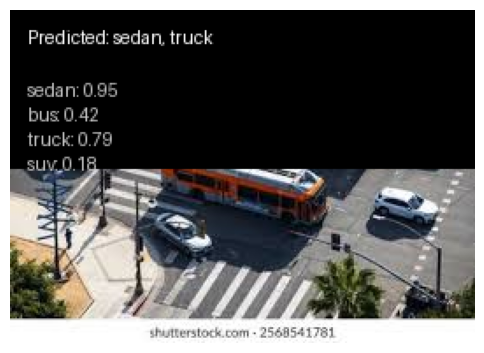

In [7]:
from google.colab import files
import torch
import timm
from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms
import matplotlib.pyplot as plt

uploaded = files.upload()
img_path = next(iter(uploaded.keys()))

ckpt = torch.load(best_path, map_location=device)
class_names = ckpt["class_names"]
img_size = ckpt["img_size"]
thr = ckpt.get("threshold", 0.5)
model_name = ckpt["model_name"]

model_inf = timm.create_model(model_name, pretrained=False, num_classes=len(class_names))
model_inf.load_state_dict(ckpt["state_dict"])
model_inf = model_inf.to(device)
model_inf.eval()

tfm = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

img = Image.open(img_path).convert("RGB")
x = tfm(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model_inf(x)
    probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()

pred_labels = [class_names[i] for i,p in enumerate(probs) if p >= thr]
if len(pred_labels) == 0:
    pred_labels = [class_names[int(probs.argmax())]]

draw_img = img.copy()
draw = ImageDraw.Draw(draw_img)

text = "Predicted: " + ", ".join(pred_labels)
probs_text = "\n".join([f"{c}: {probs[i]:.2f}" for i,c in enumerate(class_names)])

try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 20)
except:
    font = ImageFont.load_default()

draw.rectangle([(0,0),(draw_img.width,90)], fill=(0,0,0))
draw.text((10,10), text, fill=(255,255,255), font=font)
draw.text((10,40), probs_text, fill=(200,200,200), font=font)

plt.figure(figsize=(6,6))
plt.imshow(draw_img)
plt.axis("off")
plt.show()

#clip feature extract +logstic classfication

In [9]:
!pip -q install open_clip_torch scikit-learn pyyaml pillow

import os, zipfile, random, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
from PIL import Image
import open_clip
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
import joblib

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

ZIP_PATH_CANDIDATES = ["/content/archive.zip", "/content/Aerial Vehicle Detection.zip"]
zip_candidates = [p for p in ZIP_PATH_CANDIDATES if os.path.exists(p)]
if zip_candidates:
    ZIP_PATH = zip_candidates[0]
else:
    zips = [str(p) for p in Path("/content").glob("*.zip")]
    if not zips:
        raise FileNotFoundError("No .zip found in /content")
    ZIP_PATH = zips[0]

EXTRACT_DIR = Path("/content/data_full_clip_lr")
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

root = EXTRACT_DIR
subdirs = [p for p in root.iterdir() if p.is_dir()]
if len(subdirs) == 1:
    root = subdirs[0]

IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
img_files = []
for ext in IMG_EXTS:
    img_files += list(root.rglob(f"*{ext}"))
txt_files = [p for p in root.rglob("*.txt") if p.name != "classes.txt"]

if not img_files or not txt_files:
    raise RuntimeError(f"Could not find images/labels under: {root}")

imgs_by_stem = defaultdict(list)
for p in img_files:
    imgs_by_stem[p.stem].append(p)

labels_by_stem = {p.stem: p for p in txt_files}

pairs = []
for s, lbl in labels_by_stem.items():
    if s in imgs_by_stem:
        pairs.append((imgs_by_stem[s][0], lbl))

if not pairs:
    raise RuntimeError("No matching image/label pairs found")

classes_txt = list(root.rglob("classes.txt"))
id_to_name = None
if classes_txt:
    lines = [ln.strip() for ln in classes_txt[0].read_text().splitlines() if ln.strip()]
    id_to_name = {i: lines[i] for i in range(len(lines))}

DROP_CID = 1

KEEP_NAMES = ["sedan", "bus", "truck", "suv"]
name_to_id = {n:i for i,n in enumerate(KEEP_NAMES)}

ORIG_TO_NEW = {
    "car": "sedan",
    "van": "suv",
    "bus": "bus",
    "truck": "truck",
}

def parse_label(lbl_path: Path):
    lines = [ln.strip() for ln in lbl_path.read_text().splitlines() if ln.strip()]
    cids = []
    for ln in lines:
        parts = ln.split()
        if len(parts) < 5:
            continue
        cids.append(int(float(parts[0])))
    return cids

def cid_name(cid: int):
    if id_to_name and cid in id_to_name:
        return id_to_name[cid].strip()
    return str(cid)

items = []
for img_path, lbl_path in pairs:
    cids = parse_label(lbl_path)
    cids = [c for c in cids if c != DROP_CID]
    orig_names = set(cid_name(c) for c in cids)

    mapped_present = set()
    for on in orig_names:
        if on in ORIG_TO_NEW:
            mapped_present.add(ORIG_TO_NEW[on])

    present = [n for n in KEEP_NAMES if n in mapped_present]
    if not present:
        continue

    y = np.zeros(4, dtype=np.int64)
    for n in present:
        y[name_to_id[n]] = 1
    items.append((img_path, y))

if not items:
    raise RuntimeError("No usable images after filtering cycle id=1 and mapping names.")

need_per_class = 5
target_total = 20

per_class_pool = {i: [] for i in range(4)}
for img_path, y in items:
    for i in range(4):
        if y[i] == 1:
            per_class_pool[i].append((img_path, y))

for i in range(4):
    if len(per_class_pool[i]) < need_per_class:
        raise RuntimeError(f"Not enough images containing class {KEEP_NAMES[i]}: {len(per_class_pool[i])}")

selected = []
selected_keys = set()
covered = [0,0,0,0]

for i in range(4):
    pool = per_class_pool[i][:]
    random.shuffle(pool)
    for img_path, y in pool:
        k = str(img_path)
        if k in selected_keys:
            continue
        selected.append((img_path, y))
        selected_keys.add(k)
        for j in range(4):
            if y[j] == 1:
                covered[j] += 1
        if covered[i] >= need_per_class:
            break

remaining = [x for x in items if str(x[0]) not in selected_keys]
random.shuffle(remaining)
while len(selected) < target_total and remaining:
    img_path, y = remaining.pop()
    k = str(img_path)
    if k in selected_keys:
        continue
    selected.append((img_path, y))
    selected_keys.add(k)

if len(selected) != target_total:
    raise RuntimeError(f"Could only select {len(selected)} images")

random.shuffle(selected)
train_items = selected[:16]
test_items  = selected[16:20]

cov_sel = [0,0,0,0]
for _, y in selected:
    for j in range(4):
        if y[j] == 1:
            cov_sel[j] += 1

print("Selected 20 images total.")
print("Coverage in selected (images containing each class):")
for i,n in enumerate(KEEP_NAMES):
    print(n, cov_sel[i])
print("Train/Test sizes:", len(train_items), len(test_items))

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)
clip_model = clip_model.to(device)
clip_model.eval()

@torch.no_grad()
def embed_images(img_paths):
    feats = []
    for p in img_paths:
        img = Image.open(p).convert("RGB")
        x = preprocess(img).unsqueeze(0).to(device)
        f = clip_model.encode_image(x)
        f = f / (f.norm(dim=-1, keepdim=True) + 1e-12)
        feats.append(f.squeeze(0).cpu().numpy())
    return np.stack(feats, axis=0)

X_train = embed_images([str(p) for p,_ in train_items])
y_train = np.stack([y for _,y in train_items], axis=0)

X_test  = embed_images([str(p) for p,_ in test_items])
y_test  = np.stack([y for _,y in test_items], axis=0)

clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        class_weight="balanced"
    )
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

micro_f1 = f1_score(y_test, y_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
subset_acc = accuracy_score(y_test, y_pred)
label_acc = (y_test == y_pred).mean()

print("Test micro_F1:", float(micro_f1))
print("Test macro_F1:", float(macro_f1))
print("Test label_accuracy:", float(label_acc))

out_root = Path("/content/clip_lr20_multilabel_train_test")
if out_root.exists():
    shutil.rmtree(out_root)
out_root.mkdir(parents=True, exist_ok=True)

joblib.dump({
    "clip_backbone": "ViT-B-32(openai)",
    "class_names": KEEP_NAMES,
    "classifier": clf
}, out_root/"clip_lr_multilabel.joblib")

torch.save({
    "clip_backbone": "ViT-B-32(openai)",
    "class_names": KEEP_NAMES,
    "state_dict": clip_model.state_dict()
}, out_root/"clip_image_encoder.pt")

print("Saved:", str(out_root/"clip_lr_multilabel.joblib"))
print("Output folder:", out_root.as_posix())

Selected 20 images total.
Coverage in selected (images containing each class):
sedan 18
bus 5
truck 7
suv 5
Train/Test sizes: 16 4


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Test micro_F1: 0.875
Test macro_F1: 0.75
Test label_accuracy: 0.875
Saved: /content/clip_lr20_multilabel_train_test/clip_lr_multilabel.joblib
Output folder: /content/clip_lr20_multilabel_train_test
